In [5]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

In [12]:
def synthetic_data(w,b,num_examples):
    X=torch.normal(0,1,(num_examples,len(w))) #从标准正态分布（均值0，方差1）中生成 num_examples 个样本、每个样本 len(w) 个特征的随机特征矩阵 X。
    y=torch.matmul(X,w)+b
    y+=torch.normal(0,0.01,y.shape) #加上噪音
    return X,y.reshape((-1,1)) #无论 y 原来是什么形状，将张量 y 重塑为只有1列的二维矩阵（列向量）

In [15]:
true_w=torch.tensor([2,-3.4])
true_b=4.2
features,labels=synthetic_data(true_w, true_b, 1000) #生成x,y

In [16]:
print('features:', features[0],'\nlabel:', labels[0])

features: tensor([-0.4936,  0.0171]) 
label: tensor([3.1506])


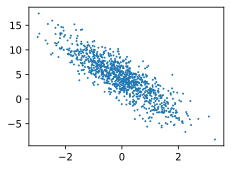

In [18]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

In [24]:
def data_iter(batch_size,features,labels):
    num_examples=len(features)
    indices=list(range(num_examples)) #成一个从 0 顺序到 num_examples-1 的整数列表
    random.shuffle(indices) #随机取
    for i in range(0,num_examples,batch_size): # 生成一个从 0 开始，到 num_examples-1 结束，步长为 batch_size 的整数序列。
        batch_indices=torch.tensor(
            indices[i:min(i+batch_size,num_examples)]) #从i到i+n的数据
        yield features[batch_indices],labels[batch_indices] #返回一个批次数据
    

In [25]:
batch_size = 10
for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break


tensor([[-1.2689, -1.1118],
        [-1.2780, -1.5253],
        [-0.6774,  1.2957],
        [-1.2310,  0.2850],
        [-1.4996,  0.5061],
        [ 0.2864, -1.0052],
        [-0.2836,  1.1903],
        [-0.3094, -0.8925],
        [ 0.5153, -0.1561],
        [-1.1060,  0.2849]]) 
 tensor([[ 5.4429],
        [ 6.8264],
        [-1.5552],
        [ 0.7736],
        [-0.5181],
        [ 8.1824],
        [-0.3996],
        [ 6.6127],
        [ 5.7640],
        [ 1.0197]])


In [39]:
#初始化：从均值为0、标准差为0.01的正态分布中采样随机数来初始化权重，并将偏置初始化为0。
#任务是更新这些参数，直到这些参数足够拟合我们的数据
#每次更新都需要计算损失函数关于模型参数的梯度
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True) 
b = torch.zeros(1, requires_grad=True)

In [30]:
def linreg(X, w, b): #@save 定义模型
    """线性回归模型"""
    return torch.matmul(X, w) + b

In [29]:
def squared_loss(y_hat, y): #@save 定义损失函数
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [31]:
def sgd(params, lr,batch_size):
    with torch.no_grad(): #with torch.no_grad(): 会临时关闭 PyTorch 的自动求导引擎
        for param in params:
            param -= lr*param.grad/batch_size
            param.grad.zero_()

In [40]:
#训练
lr = 0.03
num_epochs = 10
net = linreg
loss = squared_loss


In [41]:
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y) # X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，
        # 并以此计算关于[w,b]的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size) # 使用参数的梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.026264
epoch 2, loss 0.000094
epoch 3, loss 0.000051
epoch 4, loss 0.000051
epoch 5, loss 0.000051
epoch 6, loss 0.000051
epoch 7, loss 0.000051
epoch 8, loss 0.000051
epoch 9, loss 0.000051
epoch 10, loss 0.000051


In [42]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([-8.3923e-05,  2.8944e-04], grad_fn=<SubBackward0>)
b的估计误差: tensor([-7.0095e-05], grad_fn=<RsubBackward1>)
